# IT Support Priority Analytics Report

# Import Libraries

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

# Load Data

In [2]:
df = pd.read_csv("Support_tickets.csv")
df.head(2)

,ticket_id,day_of_week,day_of_week_num,company_id,company_size,company_size_cat,industry,industry_cat,customer_tier,customer_tier_cat,...,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment,customer_sentiment_cat,description_length,priority,priority_cat
0,1000000000,Wed,3,100015,Small,1,media,7,Basic,1,...,6,0,0,0,0,neutral,2,227,low,1
1,1000000001,Sat,6,100023,Small,1,healthcare,5,Basic,1,...,2,0,0,0,0,neutral,2,461,low,1


# Data Understanding

In [3]:
df.describe()

,ticket_id,day_of_week_num,company_id,company_size_cat,industry_cat,customer_tier_cat,org_users,region_cat,past_30d_tickets,past_90d_incidents,...,customers_affected,error_rate_pct,downtime_min,payment_impact_flag,security_incident_flag,data_loss_flag,has_runbook,customer_sentiment_cat,description_length,priority_cat
count,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,...,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.000025e+09,3.078360,100013.036780,1.900800,4.120640,1.93282,1762.044460,1.974580,3.816280,1.845720,...,182.979900,4.639622,11.115640,0.016660,0.002780,0.005060,0.567020,1.834080,369.795320,1.650000
std,1.443390e+04,1.609768,7.265389,0.804371,2.054023,0.74576,2266.438241,0.811213,2.784206,1.467774,...,427.012709,4.638842,17.294065,0.127995,0.052653,0.070954,0.495493,0.606595,104.316407,0.726299
min,1.000000e+09,1.000000,100001.000000,1.000000,1.000000,1.00000,71.000000,1.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,1.000000
25%,1.000012e+09,2.000000,100007.000000,1.000000,3.000000,1.00000,126.000000,1.000000,2.000000,1.000000,...,8.000000,1.582760,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,297.000000,1.000000
50%,1.000025e+09,3.000000,100013.000000,2.000000,3.000000,2.00000,547.000000,2.000000,3.000000,2.000000,...,31.000000,3.257528,0.000000,0.000000,0.000000,0.000000,1.000000,2.000000,368.000000,1.500000
75%,1.000037e+09,4.000000,100019.000000,3.000000,6.000000,2.00000,4799.000000,3.000000,5.000000,3.000000,...,151.000000,6.154249,17.000000,0.000000,0.000000,0.000000,1.000000,2.000000,440.250000,2.000000
max,1.000050e+09,7.000000,100025.000000,3.000000,7.000000,3.00000,5757.000000,3.000000,19.000000,12.000000,...,5757.000000,79.814565,196.000000,1.000000,1.000000,1.000000,1.000000,3.000000,815.000000,3.000000


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 33 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ticket_id               50000 non-null  int64  
 1   day_of_week             50000 non-null  str    
 2   day_of_week_num         50000 non-null  int64  
 3   company_id              50000 non-null  int64  
 4   company_size            50000 non-null  str    
 5   company_size_cat        50000 non-null  int64  
 6   industry                50000 non-null  str    
 7   industry_cat            50000 non-null  int64  
 8   customer_tier           50000 non-null  str    
 9   customer_tier_cat       50000 non-null  int64  
 10  org_users               50000 non-null  int64  
 11  region                  50000 non-null  str    
 12  region_cat              50000 non-null  int64  
 13  past_30d_tickets        50000 non-null  int64  
 14  past_90d_incidents      50000 non-null  int64  
 

In [5]:
df.isnull().sum()

ticket_id                   0
day_of_week                 0
day_of_week_num             0
company_id                  0
company_size                0
company_size_cat            0
industry                    0
industry_cat                0
customer_tier               0
customer_tier_cat           0
org_users                   0
region                      0
region_cat                  0
past_30d_tickets            0
past_90d_incidents          0
product_area                0
product_area_cat            0
booking_channel             0
booking_channel_cat         0
reported_by_role            0
reported_by_role_cat        0
customers_affected          0
error_rate_pct              0
downtime_min                0
payment_impact_flag         0
security_incident_flag      0
data_loss_flag              0
has_runbook                 0
customer_sentiment        906
customer_sentiment_cat      0
description_length          0
priority                    0
priority_cat                0
dtype: int

# Missing Value Handel

In [6]:
missing_value = df["customer_sentiment"].isna()
df.loc[missing_value,"customer_sentiment"] = np.random.choice(["Positive", "Negative", "Neutral"],size=missing_value.sum())

In [7]:
df.isnull().sum()

ticket_id                 0
day_of_week               0
day_of_week_num           0
company_id                0
company_size              0
company_size_cat          0
industry                  0
industry_cat              0
customer_tier             0
customer_tier_cat         0
org_users                 0
region                    0
region_cat                0
past_30d_tickets          0
past_90d_incidents        0
product_area              0
product_area_cat          0
booking_channel           0
booking_channel_cat       0
reported_by_role          0
reported_by_role_cat      0
customers_affected        0
error_rate_pct            0
downtime_min              0
payment_impact_flag       0
security_incident_flag    0
data_loss_flag            0
has_runbook               0
customer_sentiment        0
customer_sentiment_cat    0
description_length        0
priority                  0
priority_cat              0
dtype: int64

# Data Cleaning

In [8]:
df = df.drop(["day_of_week_num","company_size_cat","industry_cat","customer_tier_cat","region_cat","product_area_cat","booking_channel_cat","reported_by_role_cat","error_rate_pct","payment_impact_flag","security_incident_flag","data_loss_flag","has_runbook","customer_sentiment_cat","priority_cat","description_length"],axis=1)

In [90]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   ticket_id           50000 non-null  int64
 1   day_of_week         50000 non-null  str  
 2   company_id          50000 non-null  int64
 3   company_size        50000 non-null  str  
 4   industry            50000 non-null  str  
 5   customer_tier       50000 non-null  str  
 6   org_users           50000 non-null  int64
 7   region              50000 non-null  str  
 8   past_30d_tickets    50000 non-null  int64
 9   past_90d_incidents  50000 non-null  int64
 10  product_area        50000 non-null  str  
 11  booking_channel     50000 non-null  str  
 12  reported_by_role    50000 non-null  str  
 13  customers_affected  50000 non-null  int64
 14  downtime_min        50000 non-null  int64
 15  customer_sentiment  50000 non-null  str  
 16  priority            50000 non-null  str  
dtypes: i

In [92]:
df["customer_sentiment"] = df["customer_sentiment"].str.lower()
df["customer_sentiment"]

0         neutral
1         neutral
2        positive
3         neutral
4         neutral
           ...   
49995     neutral
49996     neutral
49997     neutral
49998     neutral
49999     neutral
Name: customer_sentiment, Length: 50000, dtype: str

# KPI Section

In [10]:
total_Ticket = df["ticket_id"].count()
total_Ticket

np.int64(50000)

In [11]:
high_priority_Ticket = df.groupby(df["priority"])["ticket_id"].count().reset_index()
high_priority_Ticket

,priority,ticket_id
0,high,7500
1,low,25000
2,medium,17500


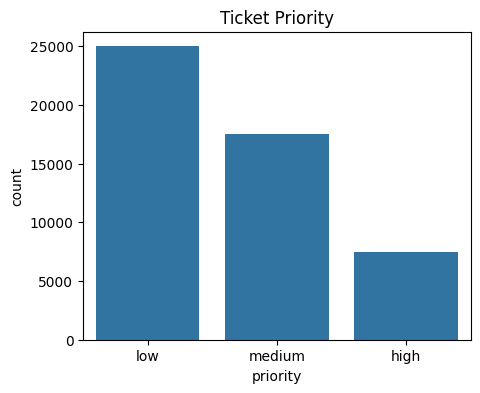

In [106]:
plt.figure(figsize=(5,4))
sns.countplot(data=df,x="priority")
plt.title("Ticket Priority")
plt.show()

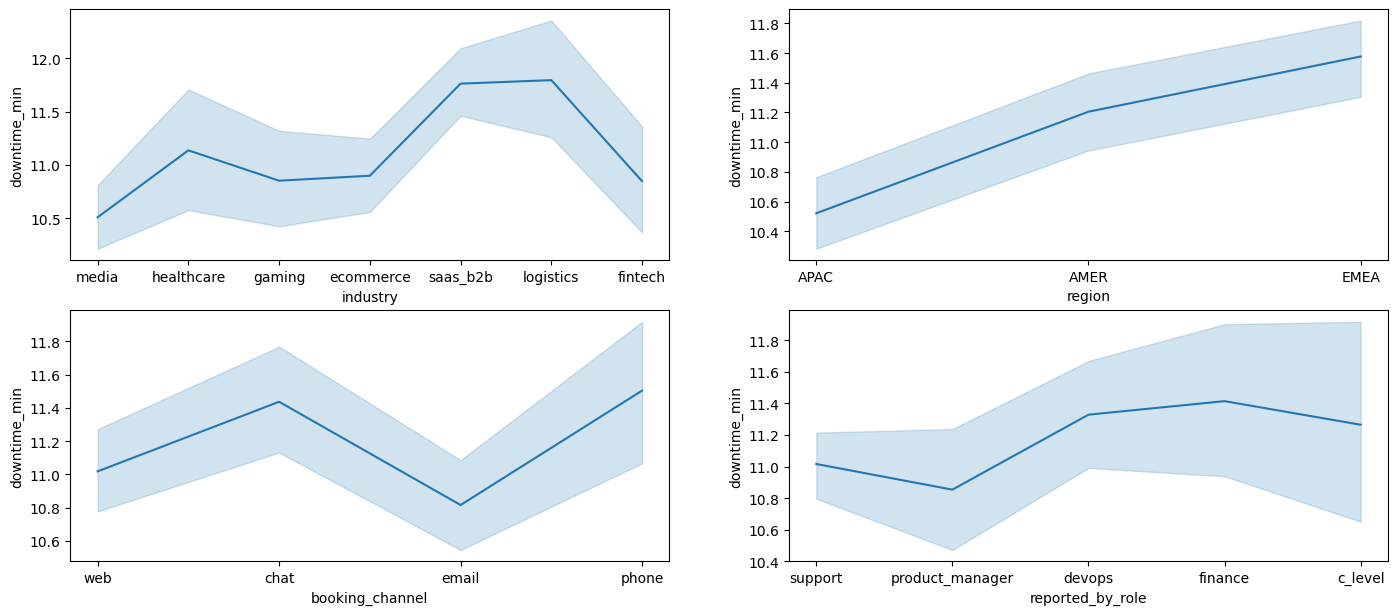

In [38]:
plt.figure(figsize=(17,15))

plt.subplot(4,2,1)
sns.lineplot(data = df,x = "industry",y="downtime_min")

plt.subplot(4,2,2)
sns.lineplot(data = df,x = "region",y="downtime_min")

plt.subplot(4,2,3)
sns.lineplot(data=df,x="booking_channel",y="downtime_min")

plt.subplot(4,2,4)
sns.lineplot(data=df,x="reported_by_role",y="downtime_min")

plt.show()

In [68]:
cous_eff = df.pivot_table(index="customer_tier",values="customers_affected",aggfunc="sum")
cous_eff

,customers_affected
customer_tier,
Basic,216634
Enterprise,3580074
Plus,5352287


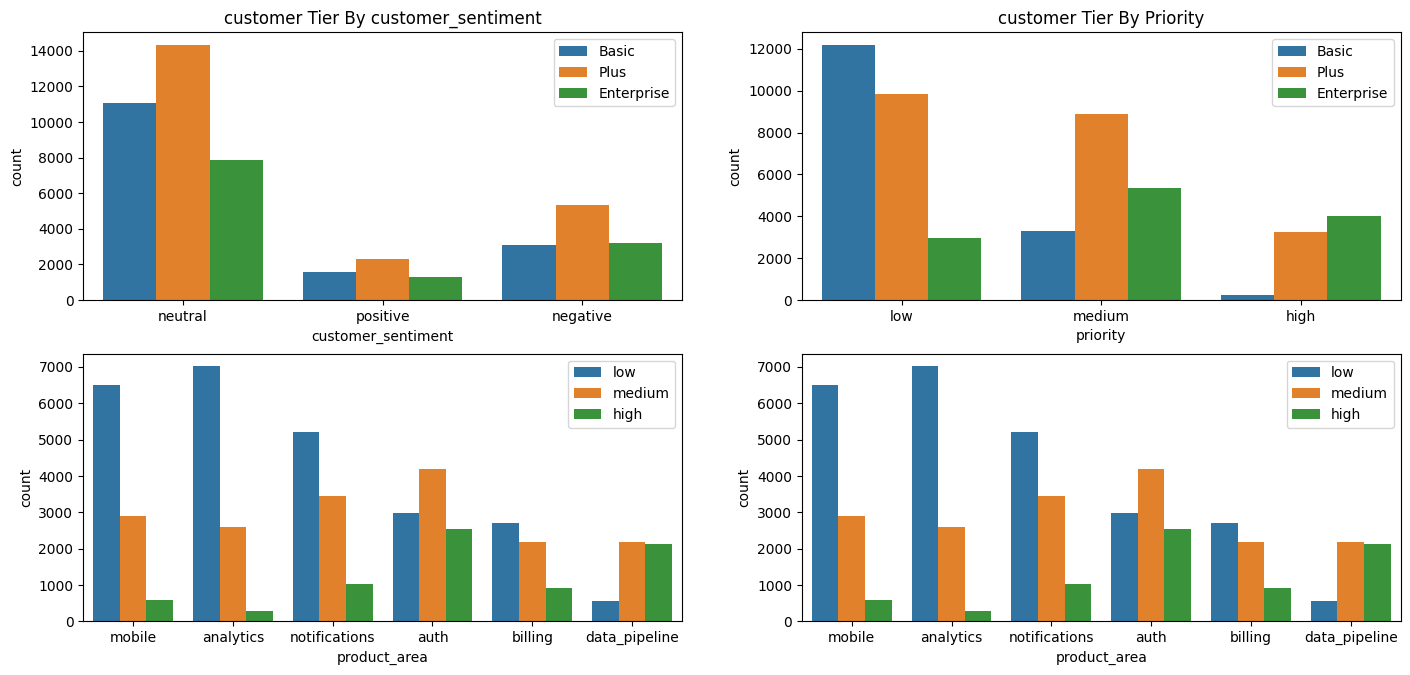

In [107]:
plt.figure(figsize=(17,16))

plt.subplot(4,2,1)
sns.countplot(data=df,x="customer_sentiment",hue="customer_tier")
plt.legend(bbox_to_anchor=(1,1))
plt.title("customer Tier By customer_sentiment")


plt.subplot(4,2,2)
sns.countplot(data=df,x="priority",hue="customer_tier")
plt.legend(bbox_to_anchor=(1,1))
plt.title("customer Tier By Priority")

plt.subplot(4,2,3)
sns.countplot(data=df,x="product_area",hue="priority")
plt.legend(bbox_to_anchor=(1,1))

plt.subplot(4,2,4)
sns.countplot(data=df,x="product_area",hue="priority")
plt.legend(bbox_to_anchor=(1,1))



plt.show()

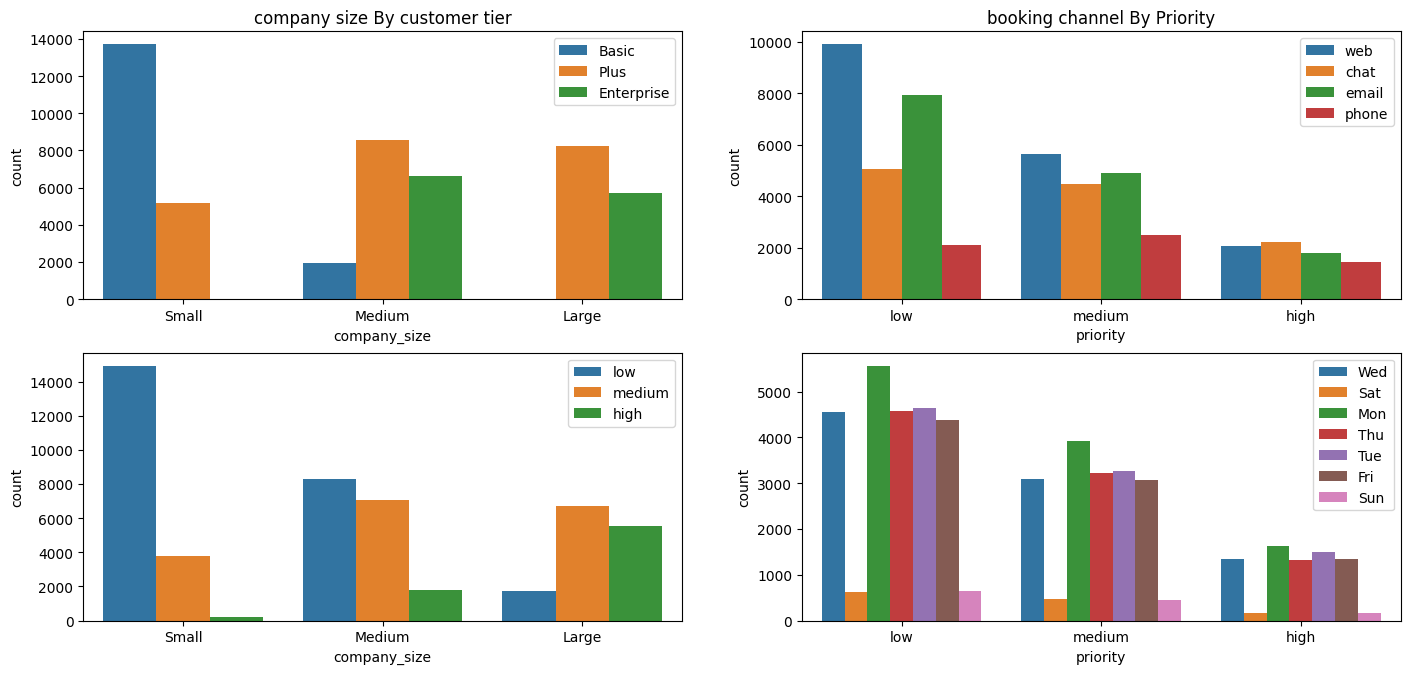

In [109]:
plt.figure(figsize=(17,16))

plt.subplot(4,2,1)
sns.countplot(data=df,x="company_size",hue="customer_tier")
plt.legend(bbox_to_anchor=(1,1))
plt.title("company size By customer tier")


plt.subplot(4,2,2)
sns.countplot(data=df,x="priority",hue="booking_channel")
plt.legend(bbox_to_anchor=(1,1))
plt.title("booking channel By Priority")

plt.subplot(4,2,3)
sns.countplot(data=df,x="company_size",hue="priority")
plt.legend(bbox_to_anchor=(1,1))

plt.subplot(4,2,4)
sns.countplot(data=df,x="priority",hue="day_of_week")
plt.legend(bbox_to_anchor=(1,1))

plt.show()

In [123]:
dp = df.pivot_table(index="priority", values="downtime_min",aggfunc="mean")
dp


,downtime_min
priority,
high,26.991467
low,4.485520
medium,13.783314


# Objective

In [ ]:
Analyze factors influencing ticket priority by examining downtime, customer impact, sentiment, company characteristics,
and historical incident trends to identify drivers of critical support incidents and improve support operations.